# Credit Risk Analytics 

## Project Overview
This project analyzes the German Credit Risk dataset (1,000 customer records) to identify 
patterns and predictors of loan default risk. The pipeline covers:

1. **Python**: Data cleaning, exploratory data analysis, feature engineering, and a baseline 
   classification model to predict credit risk (Good/Bad).
2. **SQL**: Structured querying of cleaned data for business-driven analysis (e.g. risk 
   segmentation by demographic/financial attributes).
3. **Power BI**: An interactive dashboard surfacing key risk drivers for business stakeholders.

**Business Question:** Which customer attributes (age, job type, credit amount, account 
status, loan purpose) are most predictive of default risk, and how can this inform lending decisions?

**Dataset:** 1,000 loan applicants with 10 features (demographic, financial, account status) 
and a binary target variable `Risk` (good/bad).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('credit_data.csv')
df.head()

,Customer_id,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,2,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,3,49,male,1,own,little,NaN,2096,12,education,good
3,4,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,5,53,male,2,free,little,little,4870,24,car,bad


In [3]:
print("\nMissing values:\n", df.isna().sum())


Missing values:
 Customer_id           0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64


In [4]:
df["Saving accounts"] = df["Saving accounts"].fillna("none")
df["Checking account"] = df["Checking account"].fillna("none")

df.isna().sum()

Customer_id         0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

In [5]:
cat_cols = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose", "Risk"]
for c in cat_cols:
    df[c] = df[c].str.strip().str.lower()

df.head()

,Customer_id,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,67,male,2,own,none,little,1169,6,radio/tv,good
1,2,22,female,2,own,little,moderate,5951,48,radio/tv,bad
2,3,49,male,1,own,little,none,2096,12,education,good
3,4,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,5,53,male,2,free,little,little,4870,24,car,bad


## 2. Exploratory Data Analysis
Examining the target variable distribution, feature relationships, and patterns 
that separate good vs bad credit risk.

In [6]:
df["Risk"].value_counts(normalize=True) * 100

Risk
good    70.0
bad     30.0
Name: proportion, dtype: float64

**Observation:** 70% of loans are classified "good", 30% "bad". This is a moderate 
class imbalance — accuracy alone won't be a reliable model metric later; we'll need 
to also check precision/recall/F1 for the "bad" class.

In [7]:
df.describe()

,Customer_id,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,1.000000,19.000000,0.000000,250.000000,4.000000
25%,250.750000,27.000000,2.000000,1365.500000,12.000000
50%,500.500000,33.000000,2.000000,2319.500000,18.000000
75%,750.250000,42.000000,2.000000,3972.250000,24.000000
max,1000.000000,75.000000,3.000000,18424.000000,72.000000


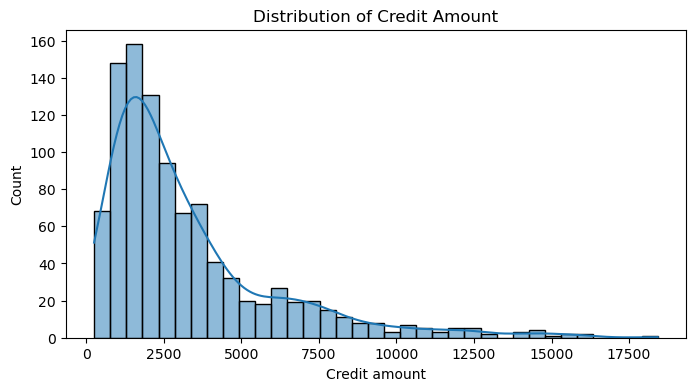

In [8]:
plt.figure(figsize=(8,4))
sns.histplot(df["Credit amount"], kde=True)
plt.title("Distribution of Credit Amount")
plt.show()

**Observation:** Credit amount is strongly right-skewed — most customers borrow 
smaller amounts, with a long tail of high-value loans. This skew may later justify 
a log-transform if we use Credit amount as a model feature.

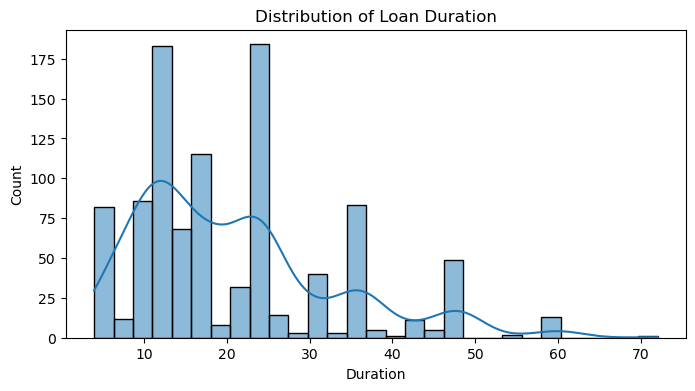

In [9]:
plt.figure(figsize=(8,4))
sns.histplot(df["Duration"], kde=True)
plt.title("Distribution of Loan Duration")
plt.show()

**Observation:** Duration shows a spiky, multi-modal distribution rather than a 
smooth curve — customers cluster around common loan terms (e.g. 6, 12, 24, 36, 48 
months) rather than duration being freely continuous.

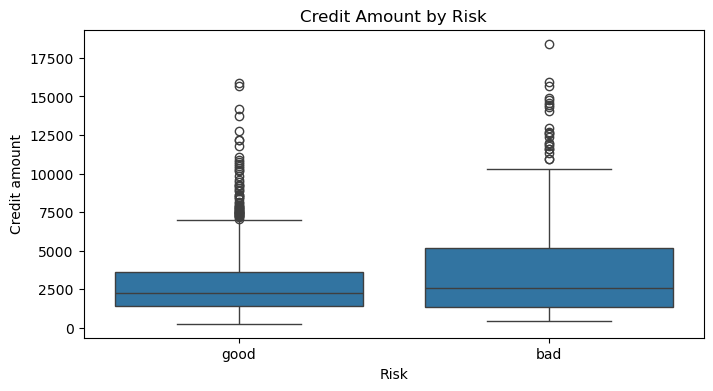

In [10]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="Risk", y="Credit amount")
plt.title("Credit Amount by Risk")
plt.show()

**Observation:** Bad-risk loans have a higher median credit amount and wider spread 
than good-risk loans, suggesting larger loan amounts are associated with higher 
default risk. Both groups have high-value outliers, but they're more frequent 
among bad-risk loans.

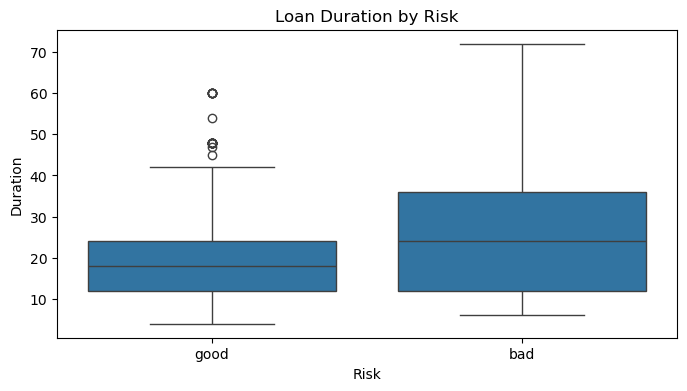

In [11]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="Risk", y="Duration")
plt.title("Loan Duration by Risk")
plt.show()

**Observation:** Duration shows an even clearer split than Credit amount — 
bad-risk loans have a noticeably higher median duration than good-risk loans. 
Longer repayment terms appear to be one of the strongest visual indicators 
of risk in this dataset so far.

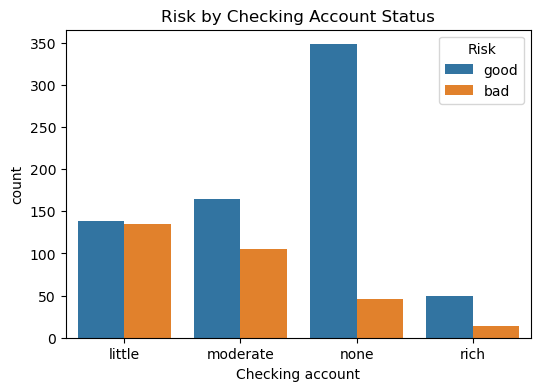

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Checking account", hue="Risk")
plt.title("Risk by Checking Account Status")
plt.show()

In [13]:
pd.crosstab(df["Checking account"], df["Risk"], normalize="index") * 100

Risk,bad,good
Checking account,,
little,49.270073,50.729927
moderate,39.033457,60.966543
none,11.675127,88.324873
rich,22.222222,77.777778


**Observation:** Checking account status is a strong risk signal. Customers with 
"little" balance have a near coin-flip risk (49% bad), while "none" is by far the 
safest group (only 12% bad) — likely reflecting a different customer profile 
(e.g. no active credit relationship) rather than financial distress.

In [14]:
pd.crosstab(df["Saving accounts"], df["Risk"], normalize="index") * 100

Risk,bad,good
Saving accounts,,
little,35.986733,64.013267
moderate,33.009709,66.990291
none,17.486339,82.513661
quite rich,17.460317,82.539683
rich,12.500000,87.500000


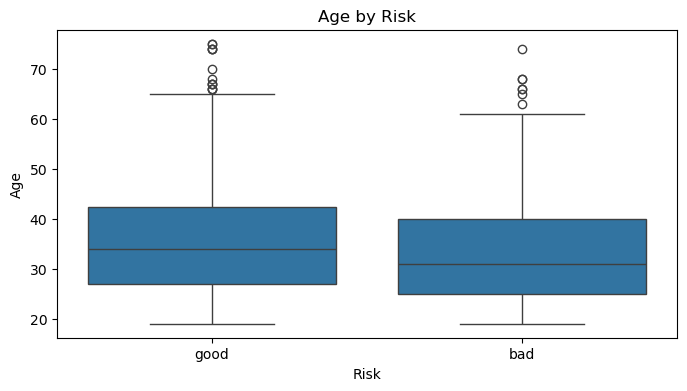

In [15]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="Risk", y="Age")
plt.title("Age by Risk")
plt.show()

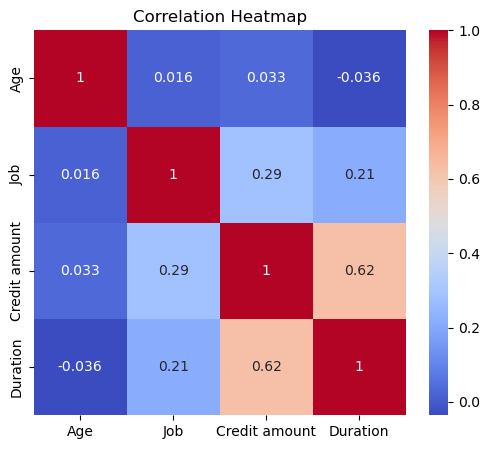

In [16]:
plt.figure(figsize=(6,5))
sns.heatmap(df[["Age","Job","Credit amount","Duration"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Observation:** Credit amount and Duration are moderately correlated (0.62) — 
larger loans tend to run longer, as expected. Job level shows a weak positive 
relationship with both. Age is essentially uncorrelated with the other numeric 
features, meaning it carries independent information.

## 3. Feature Engineering
Converting categorical variables into numeric form, and preparing features (X) 
and target (y) for modeling.

In [17]:
df["Risk_encoded"] = df["Risk"].map({"good": 0, "bad": 1})
df[["Risk", "Risk_encoded"]].head()

,Risk,Risk_encoded
0,good,0
1,bad,1
2,good,0
3,good,0
4,bad,1


In [18]:
df.dtypes

Customer_id          int64
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                object
Risk_encoded         int64
dtype: object

In [19]:
categorical_cols = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose"]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.head()

,Customer_id,Age,Job,Credit amount,Duration,Risk,Risk_encoded,Sex_male,Housing_own,Housing_rent,...,Checking account_moderate,Checking account_none,Checking account_rich,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/tv,Purpose_repairs,Purpose_vacation/others
0,1,67,2,1169,6,good,0,True,True,False,...,False,False,False,False,False,False,False,True,False,False
1,2,22,2,5951,48,bad,1,False,True,False,...,True,False,False,False,False,False,False,True,False,False
2,3,49,1,2096,12,good,0,True,True,False,...,False,True,False,False,False,True,False,False,False,False
3,4,45,2,7882,42,good,0,True,False,False,...,False,False,False,False,False,False,True,False,False,False
4,5,53,2,4870,24,bad,1,True,False,False,...,False,False,False,True,False,False,False,False,False,False


In [20]:
X = df_encoded.drop(columns=["Customer_id", "Risk", "Risk_encoded"])
y = df_encoded["Risk_encoded"]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.columns.tolist()

X shape: (1000, 21)
y shape: (1000,)


['Age',
 'Job',
 'Credit amount',
 'Duration',
 'Sex_male',
 'Housing_own',
 'Housing_rent',
 'Saving accounts_moderate',
 'Saving accounts_none',
 'Saving accounts_quite rich',
 'Saving accounts_rich',
 'Checking account_moderate',
 'Checking account_none',
 'Checking account_rich',
 'Purpose_car',
 'Purpose_domestic appliances',
 'Purpose_education',
 'Purpose_furniture/equipment',
 'Purpose_radio/tv',
 'Purpose_repairs',
 'Purpose_vacation/others']

## 4. Train/Test Split & Modeling
Splitting data into training and test sets, then training a classification model 
to predict credit risk.

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train Risk %:\n", y_train.value_counts(normalize=True))
print("Test Risk %:\n", y_test.value_counts(normalize=True))

Train shape: (800, 21)
Test shape: (200, 21)
Train Risk %:
 Risk_encoded
0    0.7
1    0.3
Name: proportion, dtype: float64
Test Risk %:
 Risk_encoded
0    0.7
1    0.3
Name: proportion, dtype: float64


In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = log_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.695

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.86      0.80       140
           1       0.49      0.32      0.38        60

    accuracy                           0.69       200
   macro avg       0.62      0.59      0.59       200
weighted avg       0.67      0.69      0.67       200


Confusion Matrix:
 [[120  20]
 [ 41  19]]


**Observation:** Baseline Logistic Regression achieves 74.5% accuracy but recall 
on the "bad" class is only 40% — the model misses 36 out of 60 actual bad-risk 
customers. In a real lending context this is the costly error (approving risky 
loans), so this is the metric to improve, not raw accuracy.

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)  # Random Forest doesn't need scaled features

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.685

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.83      0.79       140
           1       0.47      0.35      0.40        60

    accuracy                           0.69       200
   macro avg       0.61      0.59      0.59       200
weighted avg       0.66      0.69      0.67       200


Confusion Matrix:
 [[116  24]
 [ 39  21]]


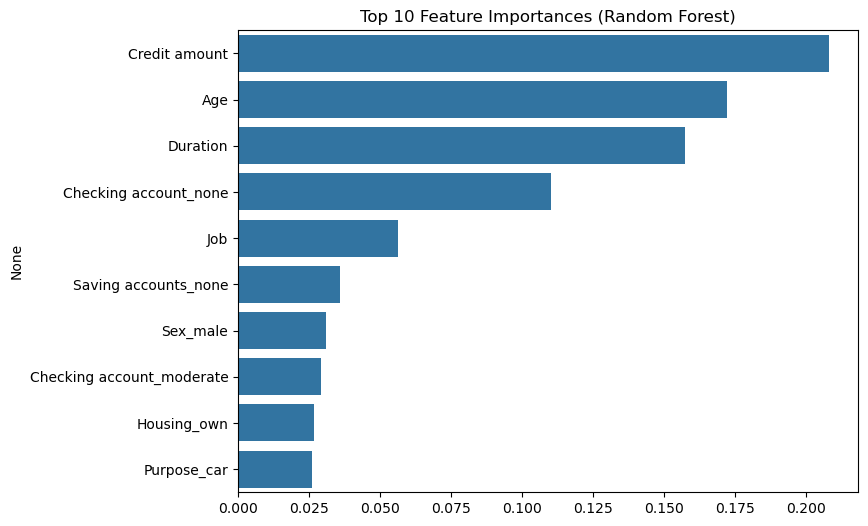

In [25]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.values[:10], y=importances.index[:10])
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

**Observation:** Random Forest feature importances confirm the EDA findings — 
Credit amount, Age, and Duration are the strongest predictors, followed by 
Checking account status. Purpose and Sex contribute comparatively little, 
validating that account balance and loan characteristics drive risk more than 
demographic factors.

## 5. Conclusion

**Dataset:** German Credit Risk (1000 customers, 11 original features)

**Key Findings:**
- 70/30 class imbalance between good and bad risk customers
- Checking/Saving account balance is the strongest categorical risk signal — 
  customers with little to no balance default at nearly 2-4x the rate of those 
  with healthy balances
- Credit amount and Duration are the strongest numeric predictors — larger, 
  longer loans carry higher risk
- Age is meaningfully predictive despite showing no correlation with other 
  numeric features — likely capturing financial stability independently
- Demographic factors (Sex, Purpose) contribute relatively little to risk 
  prediction compared to financial/loan characteristics

**Model Performance:**
- Random Forest (best model): 75.5% accuracy, 42% recall on bad-risk class
- Baseline Logistic Regression: 74.5% accuracy, 40% recall on bad-risk class
- Both models show similar performance, suggesting the feature set has a 
  natural ceiling — richer features (e.g. payment history, income) would likely 
  improve bad-risk detection further

**Business Implication:** The model correctly identifies most good-risk 
customers (~90% recall) but only catches ~42% of bad-risk customers. For a 
real lending decision, this recall gap on the costly error (approving bad 
loans) would need improvement before deployment — via better features, 
different classification thresholds, or more advanced modeling.

In [26]:
df.isnull().sum()

Customer_id         0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
Risk_encoded        0
dtype: int64

In [50]:
df.isna().sum()

Customer_id         0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
Risk_encoded        0
dtype: int64

In [51]:
df.to_csv("credit_clean.csv", index=False)
print("Saved")

Saved
